# Compare.ipynb

1. **A change is a config field.** Anything you want to test goes into `StereoConfig`, so every run is identified by its config hash. Output files are named by variant *and* hash, so editing a variant starts a fresh file rather than mixing results. §1 prints exactly which fields differ.
2. **Everything is paired.** Metrics are computed on the same scenes, and for map-mode accuracy on the same profiles. Confidence intervals come from resampling *scenes* jointly for both variants. Between-scene spread (~0.4 km) is larger than most effects worth testing, so unpaired comparisons hide them.
3. **Iterate on `dev`, decide on `holdout`.** The split hashes each GOES filename, so it is fixed and independent of the scene table's profile-count ordering. Run `holdout` once, when you're ready to make a call.


In [1]:
%matplotlib inline
from dataclasses import replace
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from contrailstereo.config import DEFAULT
from contrailstereo.validation import experiment as X
from contrailstereo.vis import compare as VC

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

# ---- paths --------------------------------------------------------------
REPO     = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
NC_PATH  = os.path.join(REPO, "data", "collocations.nc")
OUT_DIR  = os.path.join(REPO, "outputs", "experiments")
LOG_PATH = os.path.join(OUT_DIR, "log.csv")

USE_FIXTURES = True     # True: 5 offline test scenes -- checks the plumbing, proves nothing

## 1. Define the change

Change `CAND` and nothing else. The baseline is normally `DEFAULT`. Because runs are cached by config hash, the baseline is computed once and reused by every later comparison.

In [2]:
BASE = X.Variant("base", DEFAULT)
CAND = X.Variant("c14_15", replace(DEFAULT, match_channels=(14, 15)))

GATE     = 0.6      # r_map gate for map-mode metrics
SPLIT    = "dev"    # "dev" | "holdout" | "all"
N_SCENES = None     # None = every scene in the split; an int for a quick look
N_BOOT   = 2000

print(f"A = {BASE.tag}\nB = {CAND.tag}\n")
X.config_diff(BASE.cfg, CAND.cfg)

A = base_db66cff6a0
B = c14_15_2f50046542



,field,a,b
0,match_channels,"(13, 15)","(14, 15)"


## 2. Run

Resumable, with a checkpoint after every scene. Failures are recorded as `qc="error"` (not silently dropped) and retried on the next call. Variants that load identical inputs share one load per scene.

In [3]:
if USE_FIXTURES:
    # separate directory: fixture scenes share GOES filenames with real ones,
    # so a shared cache would let cropped-fixture results leak into real runs
    SRC, OUT_DIR = X.FixtureSource(os.path.join(REPO, "tests", "fixtures")), \
                   os.path.join(OUT_DIR, "fixtures")
    SPLIT = "all"                      # only 5 scenes
else:
    SRC = X.NetCDFSource(NC_PATH)

keys = X.select_keys(SRC, SPLIT, n=N_SCENES)
runs = X.run_variants(SRC, [BASE, CAND], keys, OUT_DIR)

5 scenes x 2 variants; 5 scenes need work
  [1/5]         base scene    0  qc=ok       h= 12.43
  [1/5]       c14_15 scene    0  qc=ok       h= 12.44
  [2/5]         base scene    8  qc=ok       h= 12.82
  [2/5]       c14_15 scene    8  qc=ok       h= 12.69
  [3/5]         base scene   12  qc=ok       h= 10.21
  [3/5]       c14_15 scene   12  qc=ok       h= 10.22
  [4/5]         base scene   41  qc=ok       h= 10.52
  [4/5]       c14_15 scene   41  qc=ok       h= 10.46
  [5/5]         base scene   46  qc=ok       h= 11.18
  [5/5]       c14_15 scene   46  qc=ok       h= 11.01


## 3. Headline

`delta` is always **B − A**, and `lo`/`hi` are the paired 95% interval. `call` says `better` or `worse` only when the interval excludes zero; otherwise it says `~`. For bias, read the `|bias|` row, because the sign of a bias change means nothing on its own.

The metrics fall into three groups:

- **scene** rows: the scalar `h_local` retrieval. Yield is computed over data-valid scenes; accuracy is computed on scenes `ok` in *both* variants.
- **map (own gate)** rows: what you would report for each variant.
- **map (common)** rows: the same profiles passing the gate in both variants. This is pure accuracy. A change that only moves the gate boundary shows up in coverage and own-gate rows, not here. `within` is matching precision inside a scene; `between` is scene-to-scene offset spread (the larger lever at present).

`rmse_corr` removes a leave-one-scene-out constant: the mean of the *other* scenes' mean errors, as the k = n limit of the scene-fold CV.

5 common scenes (5 ok in both), 481 common gated profiles; pipeline errors: {'base': 0, 'c14_15': 0}


,A,B,delta,lo,hi,call
metric,,,,,,
scene: yield of valid,1.000,1.000,0.000,0.000,0.000,~
scene: bias (common ok),-0.184,-0.253,-0.069,-0.133,-0.004,
scene: |bias| (common ok),0.184,0.253,0.069,0.004,0.133,worse
scene: rmse_raw (common ok),0.242,0.329,0.087,0.014,0.140,worse
scene: rmse_corr (common ok),0.196,0.264,0.068,-0.000,0.147,~
map: coverage (own gate),0.940,0.557,-0.382,-0.665,-0.223,worse
map: bias (own gate),-0.173,-0.155,0.017,-0.047,0.067,
map: |bias| (own gate),0.173,0.155,-0.017,-0.067,0.047,~
map: rmse_corr (own gate),0.441,0.486,0.045,-0.006,0.101,~


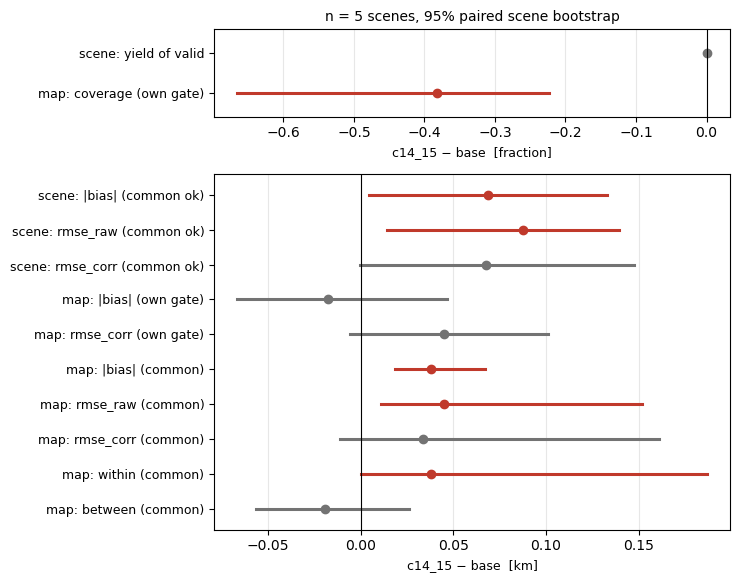

In [4]:
P = X.pair(runs[BASE.name], runs[CAND.name], gate=GATE, keys=keys)
S = X.summarise(P, n_boot=N_BOOT)

a = S.attrs
print(f"{a['n_scenes']} common scenes ({a['n_common_ok']} ok in both), "
      f"{a['n_common_prof']} common gated profiles; pipeline errors: {a['n_error']}")
if a["n_scenes"] < 30:
    print("WARNING: fewer than 30 scenes -- intervals are not meaningful")
display(S[["A", "B", "delta", "lo", "hi", "call"]])
VC.forest(S);

## 4. What changed verdict

Off-diagonal cells (red) are scenes the change moved between QC outcomes. Yield gains that come from scenes moving *into* `ok` deserve a look in §5, because they are the scenes most likely to be marginal.

c14_15,ok
base,
ok,5


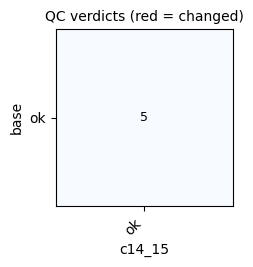

In [5]:
ct = X.verdict_flips(P)
display(ct)
VC.flips(ct);

## 5. Scene by scene

Each point is one scene's map offset: its mean error on common profiles, relative to that variant's population constant. This is the between-scene term, scene by scene. Points below the diagonal improved. A headline gain carried by two or three scenes looks very different here from one spread evenly.

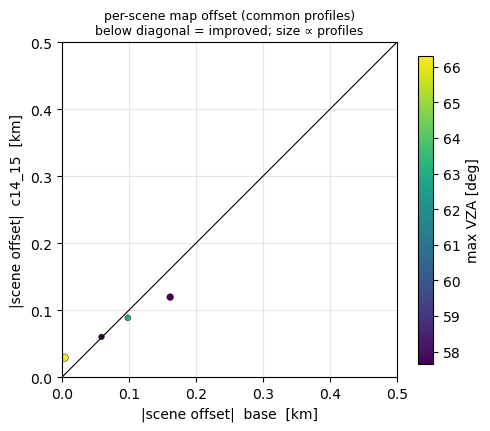

largest improvements (|offset| shrank):


,scene,vza_max,n_common,qc_a,qc_b,map_off_a,map_off_b,d_abs_off,err_a,err_b
1,8,57.657,141,ok,ok,0.162,0.120,-0.042,-0.222,-0.351
2,12,62.906,74,ok,ok,-0.098,-0.089,-0.010,-0.266,-0.257


largest degradations:


,scene,vza_max,n_common,qc_a,qc_b,map_off_a,map_off_b,d_abs_off,err_a,err_b
0,0,66.311,211,ok,ok,-0.004,0.029,0.025,0.113,0.121
3,41,57.665,55,ok,ok,-0.059,-0.060,0.001,-0.197,-0.252


In [6]:
VC.scene_scatter(P)
plt.show()
better, worse = X.movers(P, n=8)
print("largest improvements (|offset| shrank):"); display(better)
print("largest degradations:");                    display(worse)

## 6. By viewing geometry

Deltas per max-VZA band. The bias constant is always fitted on **all** scenes, so each band is judged against the correction you would actually apply. Changes aimed at oblique pairs (PSF homogenisation, for example) should show up here even if the population headline is flat.

,stratum,metric,n_scenes,A,B,delta,lo,hi,call
0,"(55, 60]",map: rmse_corr (common),3,0.385,0.374,-0.011,-0.016,0.030,n<5
1,"(55, 60]",scene: rmse_corr (common ok),3,0.122,0.208,0.086,0.019,0.185,n<5
2,"(55, 60]",scene: yield of valid,3,1.000,1.000,0.000,0.000,0.000,n<5
3,"(60, 65]",map: rmse_corr (common),1,0.163,0.362,0.199,0.150,0.218,n<5
4,"(60, 65]",scene: rmse_corr (common ok),1,0.103,0.006,-0.097,-0.104,0.173,n<5
5,"(60, 65]",scene: yield of valid,1,1.000,1.000,0.000,0.000,0.000,n<5
6,"(65, 90]",map: rmse_corr (common),1,0.565,0.601,0.037,0.027,0.039,n<5
7,"(65, 90]",scene: rmse_corr (common ok),1,0.371,0.467,0.096,0.021,0.169,n<5
8,"(65, 90]",scene: yield of valid,1,1.000,1.000,0.000,0.000,0.000,n<5


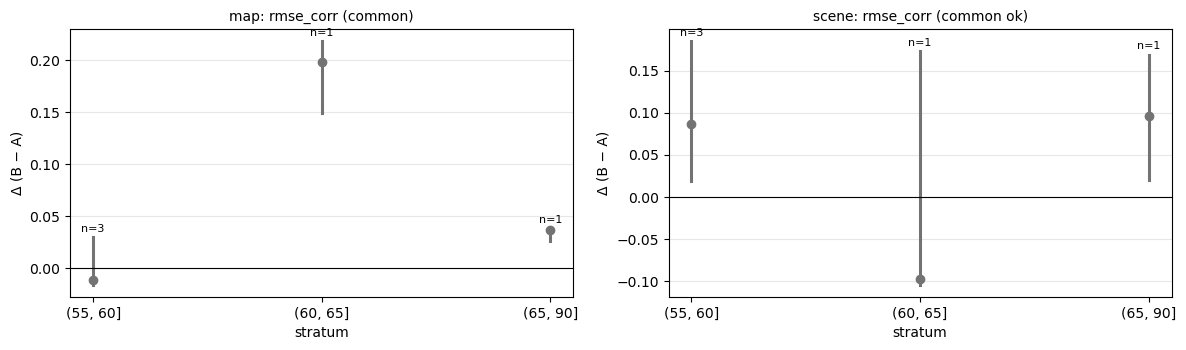

In [7]:
strat = X.by_stratum(P, col="vza_max", bins=(0, 55, 60, 65, 90), n_boot=N_BOOT)
display(strat)
fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
VC.strata(strat, "map: rmse_corr (common)", ax=axs[0])
VC.strata(strat, "scene: rmse_corr (common ok)", ax=axs[1])
plt.tight_layout();

## 7. The tail

Scenes with a map offset beyond 1 km in either variant. At present a handful of these carry a large share of the squared error, so a change that fixes or breaks one of them can swing the headline number.

In [8]:
X.tail(P, thresh_km=1.0)

,scene,vza_max,n_common,qc_a,qc_b,map_off_a,map_off_b,status


## 8. Record

Write the call down while the numbers are in front of you. The log keeps both config hashes and the split, so any row can be regenerated.

**Change:**  
**Hypothesis (written before running):**  
**Split / n scenes:**  
**Headline:**  
**Where it helped / hurt:**  
**Call:** promote / reject / inconclusive, and what would settle it

In [ ]:
NOTE = ""          # one line: the call and why
if NOTE and not USE_FIXTURES:
    X.log_summary(S, LOG_PATH, note=NOTE, split=SPLIT)
    print("logged to", LOG_PATH)